<a href="https://colab.research.google.com/github/ravindupr/Energy-Monitoring-System/blob/main/Problem_Sheet_01_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COSC 44223 / BECS 44263 — Machine Learning
## Problem Sheet 01 — Linear Regression & KNN Classification

**Instructions:**
- Answer all questions.
- Use Python with `scikit-learn`, `pandas`, and `matplotlib` where applicable.
- Clearly comment your code and explain your outputs in the markdown cells provided.
- Run each cell in order.

In [3]:
# Run this cell first — imports required for all problems
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

%matplotlib inline

---
## Problem 01: Predicting House Prices

You are given the following dataset:

| Size (sqft) | Price ($1000s) |
|-------------|----------------|
| 500         | 150            |
| 750         | 200            |
| 1000        | 250            |
| 1250        | 275            |
| 1500        | 300            |

In [4]:
# Dataset — do not modify
house_data = pd.DataFrame({
    'Size_sqft': [500, 750, 1000, 1250, 1500],
    'Price_1000s': [150, 200, 250, 275, 300]
})

print(house_data)

   Size_sqft  Price_1000s
0        500          150
1        750          200
2       1000          250
3       1250          275
4       1500          300


### Task 1.1 — Fit a Simple Linear Regression Model
Fit a simple linear regression model to predict **house price** based on **house size**.

In [5]:
# Define X (feature) and y (target)
X = house_data[['Size_sqft']]
y = house_data['Price_1000s']

# Create and fit a LinearRegression model
model_p1 = LinearRegression()
model_p1.fit(X, y)

LinearRegression()

### Task 1.2 — Slope and Intercept
Print the slope (coefficient) and intercept of the fitted line.

In [6]:
# TODO: Print the slope and intercept
slope = model_p1.coef_[0]
intercept = model_p1.intercept_

print(f"Slope: {slope}")
print(f"Intercept: {intercept}")

Slope: 0.15000000000000002
Intercept: 84.99999999999997


### Task 1.3 — Predict the Price for a 1,100 sqft House

In [7]:
# TODO: Predict the price for a house of 1100 sqft
predicted_price = model_p1.predict([[1100]])[0]

print(f"Predicted price for 1100 sqft: ${predicted_price:.2f}k")

Predicted price for 1100 sqft: $250.00k


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Task 1.4 — Plot Data Points and Regression Line

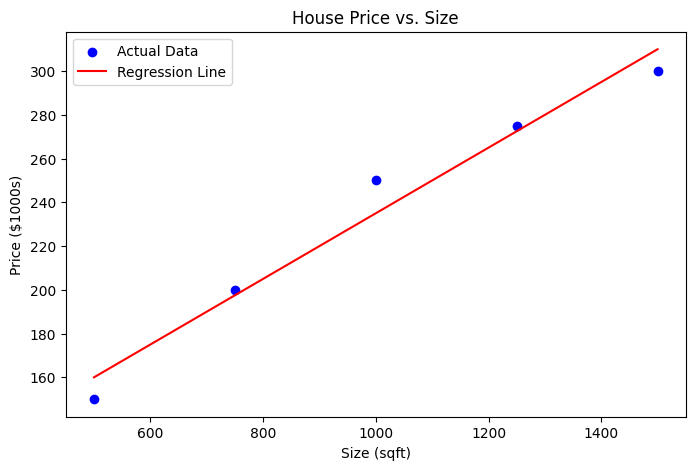

In [8]:
# TODO: Plot the original data points as a scatter plot
# TODO: Overlay the regression line
# TODO: Add axis labels, a title, and a legend

plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, model_p1.predict(X), color='red', label='Regression Line')
plt.xlabel('Size (sqft)')
plt.ylabel('Price ($1000s)')
plt.title('House Price vs. Size')
plt.legend()
plt.show()

### Task 1.5 — Compute the Mean Squared Error (MSE)

In [9]:
# TODO: Compute the MSE of the model on the training data
y_pred_p1 = model_p1.predict(X)
mse_p1 = mean_squared_error(y, y_pred_p1)
print(f"Mean Squared Error: {mse_p1:.4f}")

Mean Squared Error: 87.5000


**📝 Your explanation:** What does the MSE value tell you about the model's performance?

> 87.5000
MSE measures the average squared difference between actual and predicted values. y values are given by thousands of dollar, but MSE is only $87.5, so MSE is very lower value than the y values, so this indicates higher accuracy

---
## Problem 02: Predicting Student Exam Scores

You are provided with the following dataset of 10 students:

| Hours Studied | Attendance (%) | Sleep Hours | Exam Score (%) |
|---------------|----------------|-------------|----------------|
| 3             | 55             | 5           | 40             |
| 5             | 60             | 4           | 50             |
| 6             | 75             | 7           | 62             |
| 8             | 70             | 5           | 65             |
| 7             | 80             | 8           | 72             |
| 9             | 65             | 6           | 68             |
| 10            | 85             | 7           | 80             |
| 11            | 90             | 5           | 78             |
| 13            | 78             | 8           | 85             |
| 14            | 92             | 7           | 92             |

In [10]:
# Dataset — do not modify
student_data = pd.DataFrame({
    'Hours_Studied':  [3,  5,  6,  8,  7,  9,  10, 11, 13, 14],
    'Attendance_pct': [55, 60, 75, 70, 80, 65, 85, 90, 78, 92],
    'Sleep_Hours':    [5,  4,  7,  5,  8,  6,  7,  5,  8,  7],
    'Exam_Score':     [40, 50, 62, 65, 72, 68, 80, 78, 85, 92]
})

print(student_data)

   Hours_Studied  Attendance_pct  Sleep_Hours  Exam_Score
0              3              55            5          40
1              5              60            4          50
2              6              75            7          62
3              8              70            5          65
4              7              80            8          72
5              9              65            6          68
6             10              85            7          80
7             11              90            5          78
8             13              78            8          85
9             14              92            7          92


### Task 2.1 — Fit a Multiple Linear Regression Model
Build a model that predicts **Exam Score** using all three input features.

In [11]:
# TODO: Define X (all three features) and y (Exam Score)
X2 = student_data[['Hours_Studied', 'Attendance_pct', 'Sleep_Hours']]
y2 = student_data['Exam_Score']

# Create and fit a LinearRegression model
model_p2 = LinearRegression()
model_p2.fit(X2, y2)

LinearRegression()

### Task 2.2 — Display Model Coefficients

In [12]:
# TODO: Print the intercept and each coefficient with its feature name
print(f"Intercept: {model_p2.intercept_:.4f}")
for feature, coef in zip(X2.columns, model_p2.coef_):
    print(f"{feature} Coefficient: {coef:.4f}")

Intercept: 3.6363
Hours_Studied Coefficient: 2.8819
Attendance_pct Coefficient: 0.3780
Sleep_Hours Coefficient: 2.0046


### Task 2.3 — Make a Prediction
Predict the exam score for a student who studied **12 hours**, had **82% attendance**, and slept **6 hours**.

In [13]:
# TODO: Create the input for the new student and predict their score
new_student = [[12, 82, 6]]
predicted_score = model_p2.predict(new_student)

print(f"Predicted exam score: {predicted_score[0]:.2f}%")

Predicted exam score: 81.24%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Task 2.4 — Compute the R² Score

In [14]:
# TODO: Compute the R² score of the model
r2_p2 = r2_score(y2, model_p2.predict(X2))

print(f"R² Score: {r2_p2:.4f}")

R² Score: 0.9866


### Task 2.5 — Feature Significance Discussion

**📝 Your explanation:** Based on the coefficients, do all three variables (Hours Studied, Attendance, Sleep Hours) appear to contribute significantly to the prediction? Justify your answer.

> Yes, all three variables contribute significantly because each has a positive coefficient that directly influences the predicted exam score. While Hours Studied and Attendance provide the strongest impact by reflecting a student's academic effort and consistency, Sleep Hours provides critical context regarding their physical readiness and cognitive health. The high R^2 score, which calculated further confirms that these three specific features are highly effective at explaining the variance in the scores

---
## Problem 03: Classifying Fruit Type

You are given a dataset containing measurements of fruit:

| Weight (g) | Color Score (1–10) | Fruit Type |
|------------|---------------------|------------|
| 150        | 7                   | Apple      |
| 170        | 6                   | Apple      |
| 140        | 8                   | Apple      |
| 130        | 3                   | Orange     |
| 120        | 2                   | Orange     |
| 110        | 4                   | Orange     |

In [15]:
# Dataset — do not modify
fruit_data = pd.DataFrame({
    'Weight_g': [150, 170, 140, 130, 120, 110],
    'Color_Score': [7, 6, 8, 3, 2, 4],
    'Fruit_Type': ['Apple', 'Apple', 'Apple', 'Orange', 'Orange', 'Orange']
})

print(fruit_data)

   Weight_g  Color_Score Fruit_Type
0       150            7      Apple
1       170            6      Apple
2       140            8      Apple
3       130            3     Orange
4       120            2     Orange
5       110            4     Orange


### Task 3.1 — Build a KNN Classifier (k=3)
Build a KNN classifier using **Weight** and **Color Score** as features.

In [16]:
# TODO: Define X (Weight, Color Score) and y (Fruit Type)
X3 = fruit_data[['Weight_g', 'Color_Score']]
y3 = fruit_data['Fruit_Type']

# TODO: Create and fit a KNeighborsClassifier with k=3
knn_k3 = KNeighborsClassifier(n_neighbors=3)
knn_k3.fit(X3, y3)

KNeighborsClassifier(n_neighbors=3)

### Task 3.2 — Predict the Class for a New Fruit
Predict the fruit type for: **Weight = 135g**, **Color Score = 5**.

In [17]:
# TODO: Predict the class for the new fruit
new_fruit =[[135, 5]]
prediction_k3 = knn_k3.predict(new_fruit)

print(f"Predicted class (k=3): {prediction_k3[0]}")

Predicted class (k=3): Apple


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


### Task 3.3 — Visualize the Decision Boundary *(Optional)*
Create a 2D plot showing the decision boundary of the KNN classifier along with the data points.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


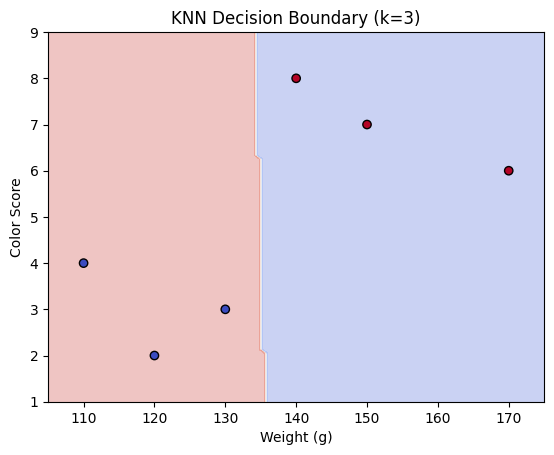

In [18]:
# TODO (Optional): Plot the decision boundary
# Hint: Use np.meshgrid to generate a grid of points, predict labels for each,
# and use plt.contourf to shade the regions.

# TODO (Optional): Plot the decision boundary
# Hint: Use np.meshgrid to generate a grid of points, predict labels for each,
# and use plt.contourf to shade the regions.

# 1. Create the grid for the background
x_min, x_max = X3['Weight_g'].min() - 5, X3['Weight_g'].max() + 5
y_min, y_max = X3['Color_Score'].min() - 1, X3['Color_Score'].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# 2. Predict the class for every point on the grid
Z = knn_k3.predict(np.c_[xx.ravel(), yy.ravel()])
Z = np.where(Z == 'Apple', 0, 1).reshape(xx.shape) # Convert names to numbers for plotting

# 3. Draw the boundary and the data points
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X3['Weight_g'], X3['Color_Score'], c=(y3 == 'Apple').astype(int), edgecolor='k', cmap='coolwarm')
plt.xlabel('Weight (g)')
plt.ylabel('Color Score')
plt.title('KNN Decision Boundary (k=3)')

plt.show()

### Task 3.4 — Try Different Values of k
Test the classifier with **k=1** and **k=5** and observe how predictions change.

In [19]:
# TODO: Fit KNN with k=1 and predict
knn_k1 = KNeighborsClassifier(n_neighbors=1)
knn_k1.fit(X3, y3)
prediction_k1 = knn_k1.predict(new_fruit)
print(f"Predicted class (k=1): {prediction_k1[0]}")

# TODO: Fit KNN with k=5 and predict
knn_k5 = KNeighborsClassifier(n_neighbors=5)
knn_k5.fit(X3, y3)
prediction_k5 = knn_k5.predict(new_fruit)
print(f"Predicted class (k=5): {prediction_k5[0]}")

Predicted class (k=1): Orange
Predicted class (k=5): Orange


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


### Task 3.5 — Feature Scaling with StandardScaler
Apply `StandardScaler` to the features, refit the KNN (k=3), and compare the prediction to the unscaled version.

In [20]:
# TODO: Scale X3 using StandardScaler
scaler = StandardScaler()
X3_scaled = scaler.fit_transform(X3)

# TODO: Fit KNN (k=3) on the scaled data
knn_scaled = KNeighborsClassifier(n_neighbors=3)
knn_scaled.fit(X3_scaled, y3)

# TODO: Scale the new fruit point and predict
new_fruit_scaled = scaler.transform([[135, 5]])
prediction_scaled = knn_scaled.predict(new_fruit_scaled)

print(f"Predicted class with scaling (k=3): {prediction_scaled[0]}")

Predicted class with scaling (k=3): Orange


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


**📝 Your explanation:** Discuss the effect of the choice of k and feature scaling on KNN performance. What are the trade-offs?

> *(Write your answer here)*